<div style="background:linear-gradient(135deg,#2e1065 0%,#6d28d9 55%,#8b5cf6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ddd6fe;font-weight:700;text-transform:uppercase">Chapter 42 · Mathematical Statistics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Joint, Marginal &amp; Conditional Densities 🎓</div>
  <div style="font-size:15px;color:#ede9fe;max-width:740px;line-height:1.6">Two variables at once. This notebook builds a joint distribution, collapses it to marginals, conditions to get one variable given another, tests independence, and explores the bivariate normal whose conditional mean is a straight line, the seed of regression.</div>
  <div style="margin-top:16px;font-size:13px;color:#c4b5fd">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
VIOLET="#7c3aed"; PINK="#db2777"; TEAL="#0d9488"
print("ready")

ready


<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 1 · THE JOINT DISTRIBUTION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Two variables, one table</div>
<div style="color:#4a5578;margin-top:6px">A joint distribution gives the probability of each PAIR of outcomes. Here is a joint PMF over weather (rain/clear) and commute (late/on-time) as a 2x2 table of probabilities that sum to 1.</div>
</div>

In [2]:
# rows = weather, cols = commute
joint = np.array([[0.20, 0.10],    # rain:  [late, on-time]
                  [0.15, 0.55]])   # clear: [late, on-time]
print("joint P(weather, commute):")
print(joint)
print(f"sums to 1? {joint.sum():.2f}")
print(f"P(rain AND late) = {joint[0,0]:.2f}")

joint P(weather, commute):
[[0.2  0.1 ]
 [0.15 0.55]]
sums to 1? 1.00
P(rain AND late) = 0.20


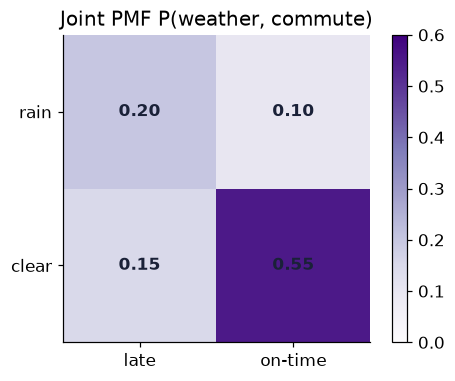

In [3]:
fig,ax=plt.subplots(figsize=(4.6,3.6))
im=ax.imshow(joint, cmap="Purples", vmin=0, vmax=0.6)
for i in range(2):
    for j in range(2):
        ax.text(j,i,f"{joint[i,j]:.2f}",ha="center",va="center",fontweight="bold",color="#1a2138")
ax.set_xticks([0,1],["late","on-time"]); ax.set_yticks([0,1],["rain","clear"])
ax.set_title("Joint PMF P(weather, commute)"); plt.colorbar(im,fraction=0.046); plt.tight_layout(); plt.show()

The joint distribution captures everything about how the two variables behave together. Each cell is the probability of one specific combination, and the four cells sum to 1. From this single table we can recover every other quantity in this chapter.

<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · MARGINAL DISTRIBUTIONS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Collapsing to one variable</div>
<div style="color:#4a5578;margin-top:6px">A marginal distribution describes one variable on its own, obtained by SUMMING the joint over the other (for densities, integrating it out).</div>
</div>

In [4]:
p_weather = joint.sum(axis=1)   # sum over commute
p_commute = joint.sum(axis=0)   # sum over weather
print(f"marginal P(weather): rain={p_weather[0]:.2f}, clear={p_weather[1]:.2f}")
print(f"marginal P(commute): late={p_commute[0]:.2f}, on-time={p_commute[1]:.2f}")

marginal P(weather): rain=0.30, clear=0.70
marginal P(commute): late=0.35, on-time=0.65


Summing each row gives the marginal for weather (30% rain, 70% clear); summing each column gives the marginal for commute (35% late, 65% on-time). "Marginal" is literally the total you would write in the margin of the table, the variable on its own, ignoring the other.

<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 3 · CONDITIONAL &amp; INDEPENDENCE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One variable given another</div>
<div style="color:#4a5578;margin-top:6px">The conditional distribution f(y|x) = f(x,y) / f_X(x) re-normalizes one row (or column) to sum to 1. If conditioning changes nothing, the variables are independent.</div>
</div>

In [5]:
# P(commute | rain): divide the rain row by P(rain)
p_commute_given_rain = joint[0] / p_weather[0]
print(f"P(commute | rain):  late={p_commute_given_rain[0]:.3f}, on-time={p_commute_given_rain[1]:.3f}")
print(f"compare marginal P(commute): late={p_commute[0]:.3f}  -> differs, so DEPENDENT")

# independence check: is joint == outer product of marginals?
indep = np.outer(p_weather, p_commute)
print(f"\nwould-be-independent joint:\n{indep.round(3)}")
print(f"matches actual joint? {np.allclose(joint, indep)}")

P(commute | rain):  late=0.667, on-time=0.333
compare marginal P(commute): late=0.350  -> differs, so DEPENDENT

would-be-independent joint:
[[0.105 0.195]
 [0.245 0.455]]
matches actual joint? False


Given rain, the chance of being late jumps from the unconditional 35% to 67%. Because conditioning changed the distribution, weather and commute are **dependent**. The formal test: they are independent only if the joint equals the product of the marginals, and here it does not.

<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 4 · THE BIVARIATE NORMAL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Correlated continuous variables</div>
<div style="color:#4a5578;margin-top:6px">The bivariate normal is the joint distribution of two correlated Gaussians. Its shape is set by a covariance matrix; the correlation rho tilts the cloud.</div>
</div>

In [6]:
mean = [0, 0]
rho = 0.75
cov = [[1, rho],[rho, 1]]
xy = rng.multivariate_normal(mean, cov, size=5000)
print(f"target correlation rho = {rho}")
print(f"sample covariance matrix:\n{np.cov(xy.T).round(3)}")
print(f"sample correlation = {np.corrcoef(xy.T)[0,1]:.3f}")

target correlation rho = 0.75
sample covariance matrix:
[[0.999 0.726]
 [0.726 0.976]]
sample correlation = 0.735


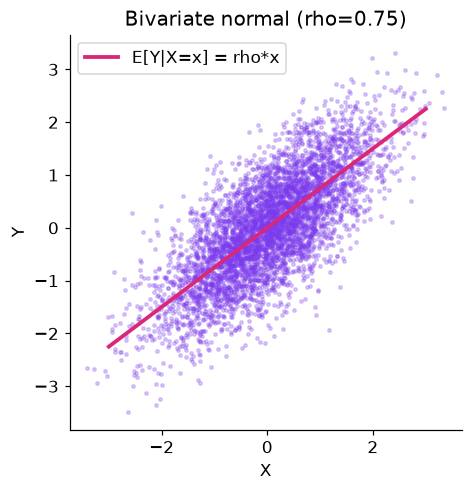

In [7]:
fig,ax=plt.subplots(figsize=(4.6,4.6))
ax.scatter(xy[:,0], xy[:,1], s=5, alpha=0.25, color=VIOLET)
xs=np.linspace(-3,3,50); ax.plot(xs, rho*xs, color=PINK, lw=2.5, label="E[Y|X=x] = rho*x")
ax.set_aspect("equal"); ax.set_xlabel("X"); ax.set_ylabel("Y")
ax.set_title(f"Bivariate normal (rho={rho})"); ax.legend()
plt.tight_layout(); plt.show()

The cloud tilts because X and Y are correlated. The pink line is the **conditional mean** E[Y | X = x], and for the bivariate normal it is exactly a straight line through the data, rho*x here. That straight conditional mean is the theoretical seed of linear regression (Part XII).

<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 5 · JOINT vs CONDITIONAL IN ML</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Generative and discriminative models</div>
<div style="color:#4a5578;margin-top:6px">The joint-vs-conditional split is one of the deepest divides in machine learning. A generative model learns the joint P(x, y); a discriminative model learns only the conditional P(y | x).</div>
</div>

In [8]:
# from the joint we can get BOTH a discriminative conditional and a generative joint
print("Discriminative view  P(commute | weather):")
for i,w in enumerate(["rain","clear"]):
    cond = joint[i]/joint[i].sum()
    print(f"   given {w:5s}: late={cond[0]:.2f}, on-time={cond[1]:.2f}")
print("\nGenerative view  P(weather, commute): the full joint table above.")
print("Discriminative (logistic reg, LLMs) models P(y|x); generative (naive Bayes, VAEs) models the joint.")

Discriminative view  P(commute | weather):
   given rain : late=0.67, on-time=0.33
   given clear: late=0.21, on-time=0.79

Generative view  P(weather, commute): the full joint table above.
Discriminative (logistic reg, LLMs) models P(y|x); generative (naive Bayes, VAEs) models the joint.


A spam classifier and a language model are **discriminative**: they estimate P(label | features) or P(next token | context) directly. A generative model (naive Bayes, a VAE, a diffusion model) learns the full **joint** distribution and can sample new data from it. Both are views of the same joint distribution you built in Demo 1.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ What you built</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You built a joint distribution, recovered its marginals, conditioned to get one variable given another, tested independence, explored the bivariate normal and its linear conditional mean, and saw the joint-vs-conditional split that separates generative from discriminative models. The joint distribution is the master object; everything else is derived from it.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>